['Sales_Data_2019\\Sales_April_2019.csv', 'Sales_Data_2019\\Sales_August_2019.csv', 'Sales_Data_2019\\Sales_December_2019.csv', 'Sales_Data_2019\\Sales_February_2019.csv', 'Sales_Data_2019\\Sales_January_2019.csv', 'Sales_Data_2019\\Sales_July_2019.csv', 'Sales_Data_2019\\Sales_June_2019.csv', 'Sales_Data_2019\\Sales_March_2019.csv', 'Sales_Data_2019\\Sales_May_2019.csv', 'Sales_Data_2019\\Sales_November_2019.csv', 'Sales_Data_2019\\Sales_October_2019.csv', 'Sales_Data_2019\\Sales_September_2019.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          6000 non-null   int64  
 1   Product           6000 non-null   object 
 2   Quantity Ordered  6000 non-null   int64  
 3   Price Each        6000 non-null   float64
 4   Order Date        6000 non-null   object 
 5   Purchase Address  6000 non-null   object 
dtypes: flo

C:\Users\mohda\AppData\Local\Temp\ipykernel_17188\3785604341.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


Highest Sales: 274726.96
Month: 2
Lowest Sales: 236432.71
Month: 4


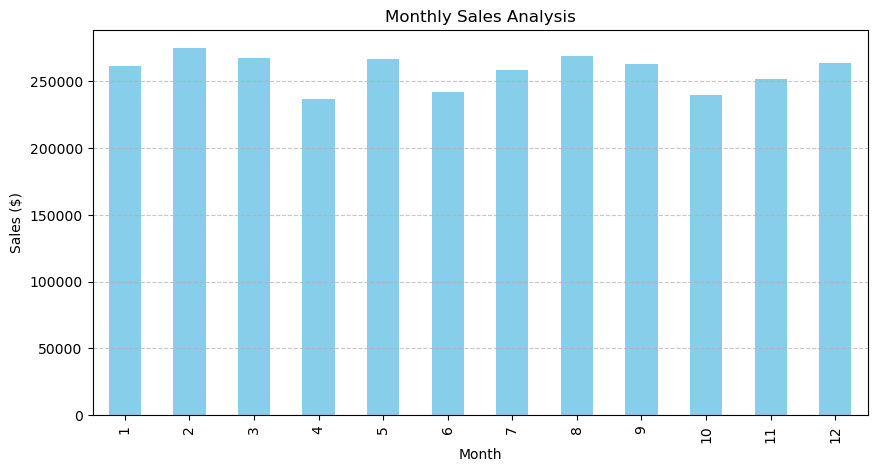

Maximum Orders:288
Best Advertisement Hour:22:00


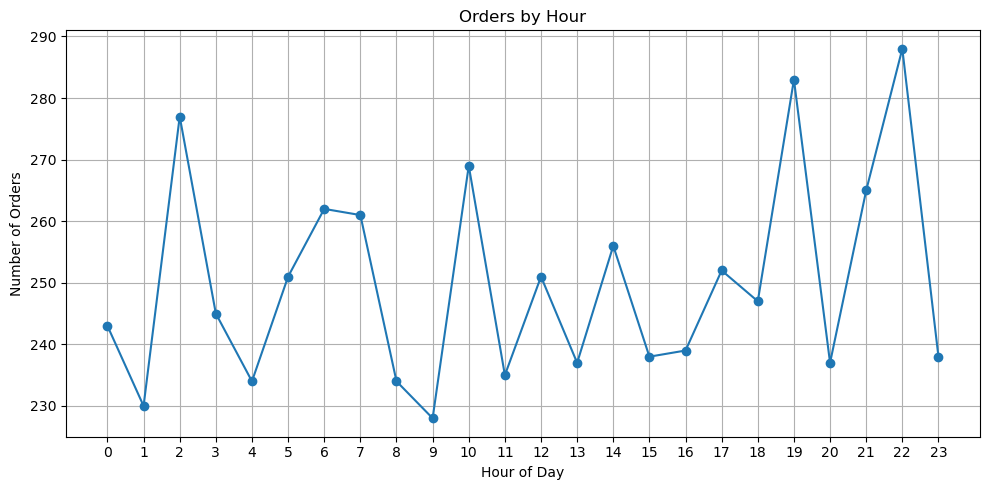

Highest Revenue Product: iPhone
Revenue: $1116500.0

Lowest Revenue Product: AAA Batteries (4-pack)
Revenue: $4,434.17
Highest Order City: Dallas
Orders: 1032

Lowest Orders City: Los Angeles
Orders: 958


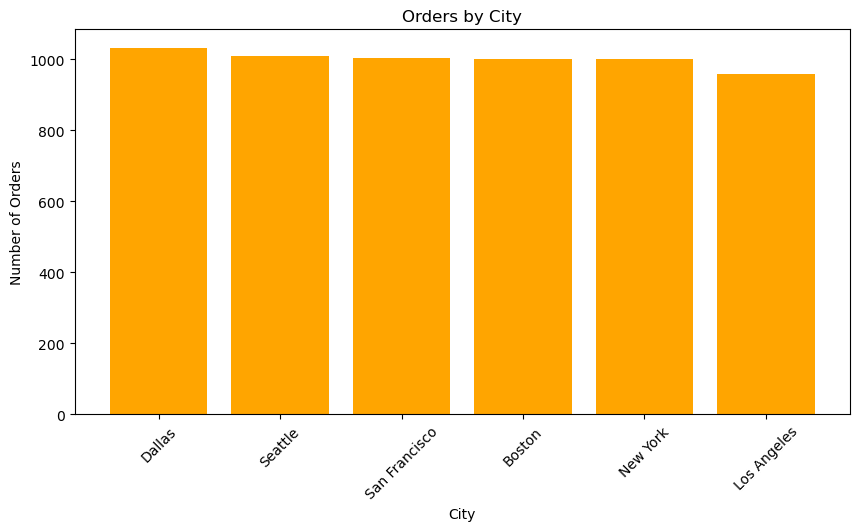

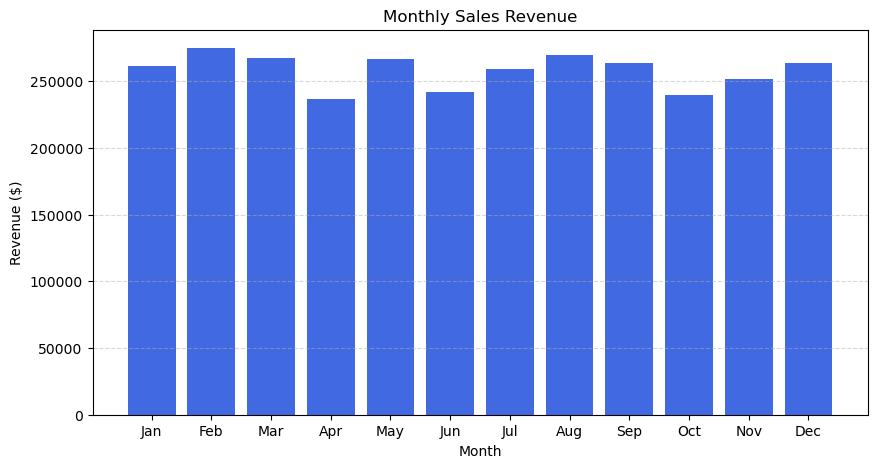

Highest Revenue Month: Feb
Revenue: 274726.96

Lowest Revenue Month: Apr
Revenue: 236432.71


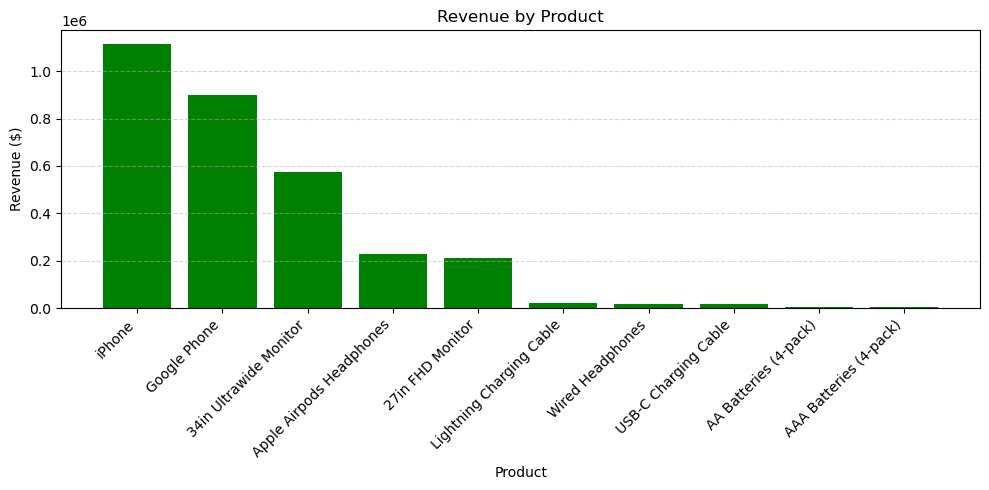

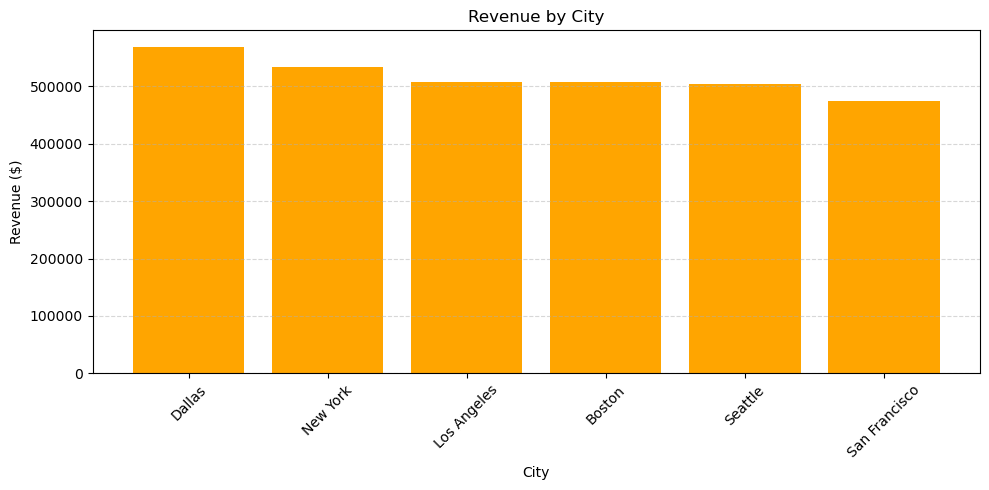

Highest Revenue City: Dallas
Revenue: 569087.01

Lowest Revenue City: San Francisco
Revenue: 474446.56


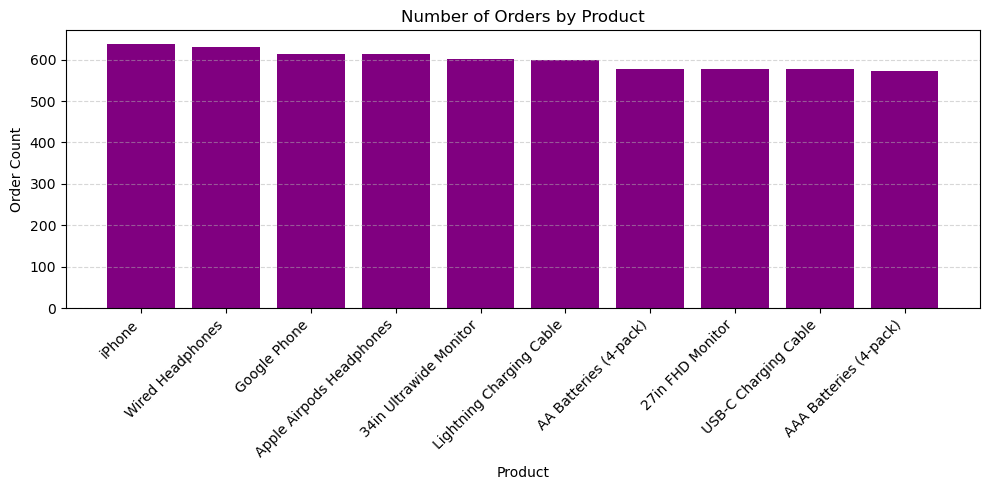

Most Ordered Product: iPhone
Order Count: 639

Least Ordered Product: AAA Batteries (4-pack)
Order Count: 572


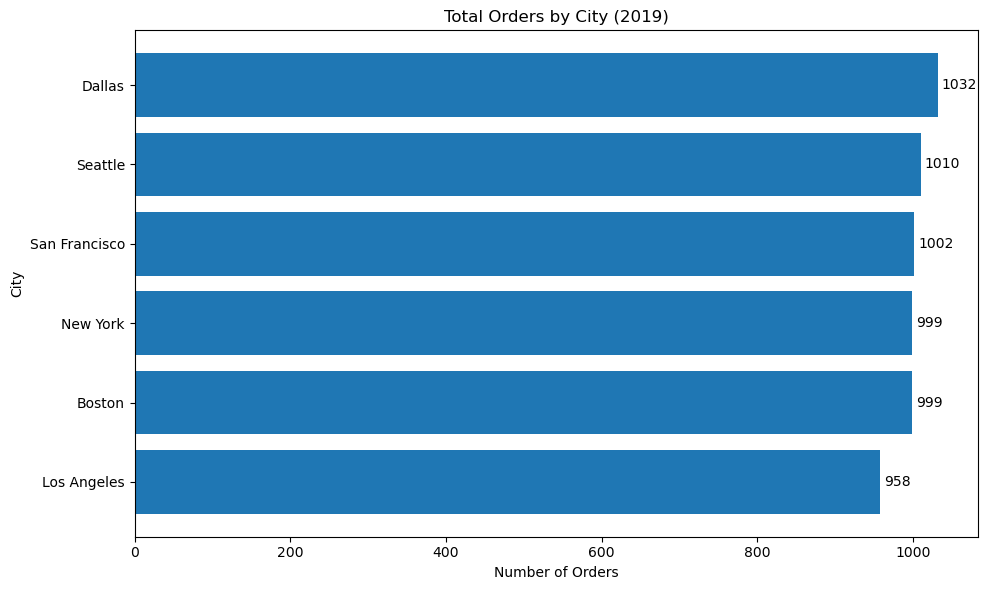

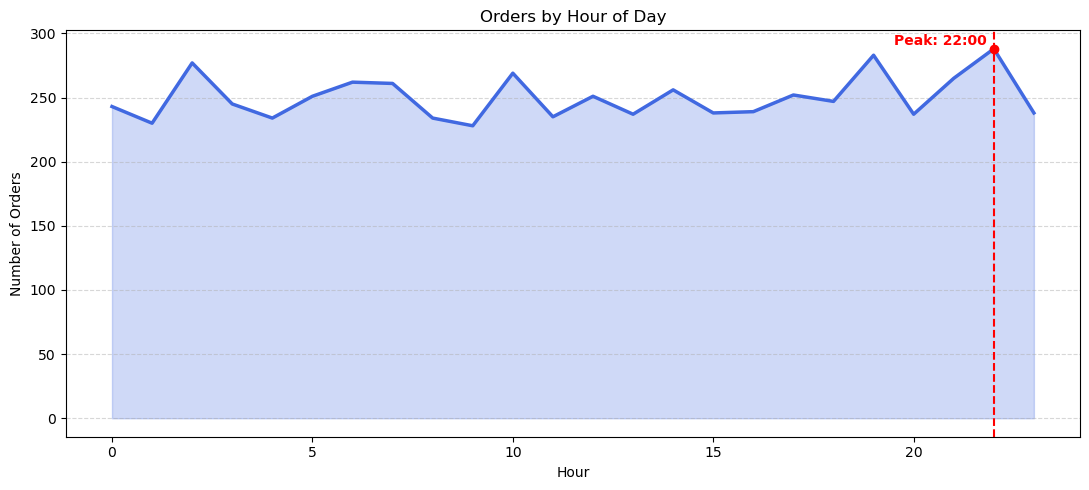

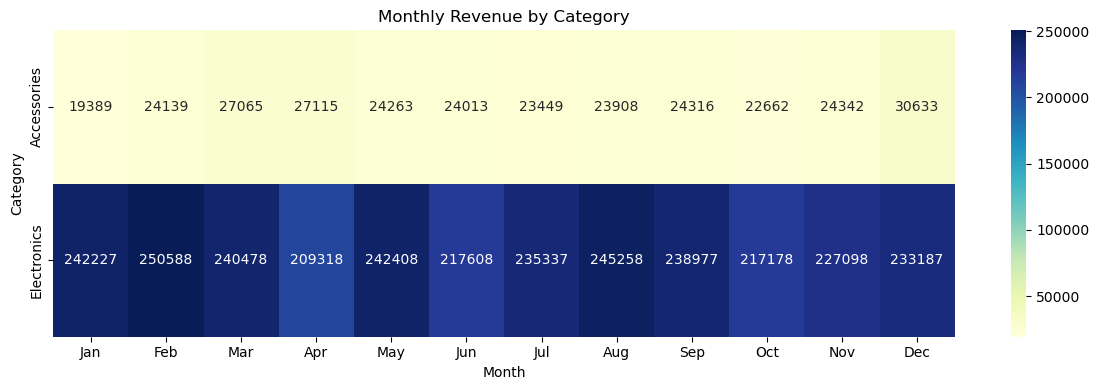

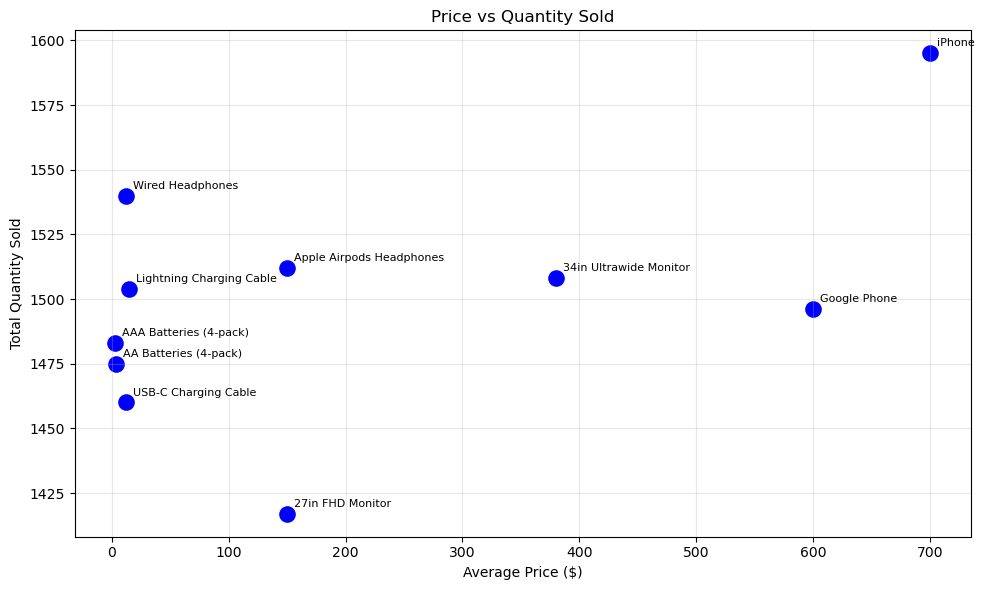

=== Key Insights ===
1. High-priced products generally sell in lower quantities.
2. Low-priced products like cables and batteries sell in higher quantities.
3. iPhone generated high sales despite its high price.
4. Accessories have higher order volume, while electronics generate higher revenue.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import glob
file = "Sales_Data_2019"

files = glob.glob(file + "/*.csv")
print(files)
df = pd.concat((pd.read_csv(file)
for file in files), 
ignore_index = True)

df.shape
df.info()
print("Dataset Shape:", df.shape)

print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()
df = df.dropna()

print("Shape after cleaning:", df.shape)

df["Sales"] = df["Quantity Ordered"] * df["Price Each"]
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Month"] = df["Order Date"].dt.month

monthly_sales = df.groupby("Month")["Sales"].sum()

print("Highest Sales:", monthly_sales.max())
print("Month:", monthly_sales.idxmax())
print("Lowest Sales:", monthly_sales.min())
print("Month:", monthly_sales.idxmin())
plt.figure(figsize=(10,5))

monthly_sales.plot(kind="bar", color="skyblue")

plt.title("Monthly Sales Analysis")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
df["Hour"] = df["Order Date"].dt.hour

hourly_orders = df.groupby("Hour")["Order ID"].count().reset_index()
hourly_orders.columns = ["Hour", "Order Count"]

print(f"Maximum Orders:{hourly_orders['Order Count'].max()}")
print(f"Best Advertisement Hour:{hourly_orders.loc[hourly_orders['Order Count'].idxmax(),'Hour']}:00")

plt.figure(figsize=(10,5))
plt.plot(hourly_orders["Hour"], hourly_orders["Order Count"], marker="o")
plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(0,24))
plt.grid(True)
plt.tight_layout()
plt.show()

product_sales = df.groupby("Product")["Sales"].sum().reset_index()
product_sales = product_sales.sort_values(by="Sales", ascending=False).reset_index(drop=True)

print(f"Highest Revenue Product: {product_sales.iloc[0] ['Product']}")
print(f"Revenue: ${product_sales.iloc[0] ['Sales']}")
print(f"\nLowest Revenue Product: {product_sales.iloc[-1] ['Product']}")
print(f"Revenue: ${product_sales.iloc[-1] ['Sales']:,.2f}")
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df["Month Name"] = df["Month"].map(month_names)
df["City"] = df["Purchase Address"].apply(lambda x: x.split(",")[1].strip())

city_orders = df.groupby("City")["Order ID"].count().reset_index()
city_orders.columns = ["City", "Order Count"]
city_orders = city_orders.sort_values(by="Order Count", ascending=False).reset_index(drop=True)

print("Highest Order City:", city_orders.iloc[0]["City"])
print("Orders:", city_orders.iloc[0]["Order Count"])

print("\nLowest Orders City:", city_orders.iloc[-1]["City"])
print("Orders:", city_orders.iloc[-1]["Order Count"])

plt.figure(figsize=(10, 5))
plt.bar(city_orders["City"], city_orders["Order Count"], color="orange")
plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

monthly_sales = df.groupby(["Month", "Month Name"]) ["Sales"].sum().reset_index()
monthly_sales = monthly_sales.sort_values("Month")

plt.figure(figsize=(10,5))
plt.bar(monthly_sales["Month Name"], monthly_sales["Sales"], color="royalblue")
plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

print("Highest Revenue Month:", monthly_sales.loc[monthly_sales["Sales"].idxmax(), "Month Name"])
print("Revenue:", monthly_sales["Sales"].max())
print("\nLowest Revenue Month:", monthly_sales.loc[monthly_sales["Sales"].idxmin(), "Month Name"])
print("Revenue:", monthly_sales["Sales"].min())

plt.figure(figsize=(10, 5))
plt.bar(product_sales["Product"], product_sales["Sales"], color="green")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

city_sales = df.groupby("City")["Sales"].sum().reset_index()
city_sales = city_sales.sort_values(by="Sales", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(city_sales["City"], city_sales["Sales"], color="orange")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Highest Revenue City:", city_sales.iloc[0]["City"])
print("Revenue:", city_sales.iloc[0]["Sales"])
print()
print("Lowest Revenue City:", city_sales.iloc[-1]["City"])
print("Revenue:", city_sales.iloc[-1]["Sales"])
product_orders = df.groupby("Product")["Order ID"].count().reset_index()
product_orders.columns = ["Product", "Order Count"]
product_orders = product_orders.sort_values(by="Order Count", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(product_orders["Product"], product_orders["Order Count"], color="purple")
plt.title("Number of Orders by Product")
plt.xlabel("Product")
plt.ylabel("Order Count")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Most Ordered Product:", product_orders.iloc[0]["Product"])
print("Order Count:", product_orders.iloc[0]["Order Count"])
print()
print("Least Ordered Product:", product_orders.iloc[-1]["Product"])
print("Order Count:", product_orders.iloc[-1]["Order Count"])

city_sorted = city_orders.sort_values("Order Count")
plt.figure(figsize=(10, 6))
bars = plt.barh(city_sorted["City"], city_sorted["Order Count"])
for bar, value in zip(bars, city_sorted["Order Count"]):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f"{value}", va="center")

plt.title("Total Orders by City (2019)")
plt.xlabel("Number of Orders")
plt.ylabel("City")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(hourly_orders["Hour"], hourly_orders["Order Count"], color="royalblue", linewidth=2.5)
plt.fill_between(hourly_orders["Hour"], hourly_orders["Order Count"], color="royalblue", alpha=0.25)
peak_hour = hourly_orders.loc[hourly_orders["Order Count"].idxmax(), "Hour"]
peak_value = hourly_orders["Order Count"].max()
plt.axvline(x=peak_hour, color="red", linestyle="--", linewidth=1.5)
plt.scatter(peak_hour, peak_value, color="red", zorder=5)
plt.text(peak_hour - 2.5, peak_value + 3, f"Peak: {peak_hour}:00", color="red", fontsize=10, fontweight="bold");
plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

def get_category(product):
    if any(x in product for x in ['Laptop', 'Phone', 'iPhone', 'Monitor', 'TV']):
        return 'Electronics'
    elif any(x in product for x in ['Cable', 'Batteries', 'Headphones', 'Earbuds']):
        return 'Accessories'
    elif any(x in product for x in ['Washing', 'Dryer', 'Fridge']):
        return 'Appliances'
    else:
        return 'Other'

df['Category'] = df['Product'].apply(get_category)

heatmap_data = df.pivot_table(values="Sales", index="Category", columns="Month Name", aggfunc="sum")
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data = heatmap_data[month_order]

plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Monthly Revenue by Category")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# product-wise average price and total quantity 
product_stats = df.groupby('Product').agg(Avg_Price=('Price Each', 'mean'), Total_Qty=('Quantity Ordered', 'sum')).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(product_stats["Avg_Price"], product_stats["Total_Qty"], color="blue", s=120)
for i in range(len(product_stats)):
    plt.annotate(product_stats["Product"][i], xy=(product_stats["Avg_Price"][i], product_stats["Total_Qty"][i]),
                 xytext=(5, 5), textcoords="offset points", fontsize=8)
plt.title("Price vs Quantity Sold")
plt.xlabel("Average Price ($)")
plt.ylabel("Total Quantity Sold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=== Key Insights ===")
print("1. High-priced products generally sell in lower quantities.")
print("2. Low-priced products like cables and batteries sell in higher quantities.")
print("3. iPhone generated high sales despite its high price.")
print("4. Accessories have higher order volume, while electronics generate higher revenue.")



## Task 2 conclusion

- Monthly revenue was analyzed.
- City-wise sales performance was compared.
- Product-wise revenue and order count were analyzed.
- Peak ordering hour was identified.
- Product price and quantity relationship was visualized using a scatter plot.
- Monthly category revenue was analyzed using a heatmap.